In [2]:
#Import visualization libraries and custom modules
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from data_loader import DataLoader
from risk_analyzer import RiskAnalyzer

In [3]:
#Load and preprocess the dataset
loader = DataLoader("Louis Vuitton Stock Price History.csv")
print(loader)
print(f"Total trading days: {len(loader)}")

MarketDataLoader for file: Louis Vuitton Stock Price History.csv
Rows: 2561
Date range: 2016-04-25 00:00:00 to 2026-04-24 00:00:00

Total trading days: 2561


In [4]:

#run full analysis, computes daily returns, volatility, moving averages, and risk labels
analyzer = RiskAnalyzer(loader)
results = analyzer.run_analysis()
print(analyzer)
print(f"\nMax Drawdown: {analyzer.compute_max_drawdown():.2%}")
print(results[["Date","Price","Daily_Return","Volatility","Risk_Level"]].head(10))

RiskAnalyzer | Window: 20 days | Risk Threshold: 0.015


Max Drawdown: -51.49%
        Date   Price  Daily_Return  Volatility Risk_Level
0 2016-04-25  148.80           NaN         NaN     normal
1 2016-04-26  147.55     -0.008401         NaN     normal
2 2016-04-27  147.20     -0.002372         NaN     normal
3 2016-04-28  149.40      0.014946         NaN     normal
4 2016-04-29  145.10     -0.028782         NaN     normal
5 2016-05-02  147.25      0.014817         NaN     normal
6 2016-05-03  144.70     -0.017317         NaN     normal
7 2016-05-04  143.65     -0.007256         NaN     normal
8 2016-05-05  144.40      0.005221         NaN     normal
9 2016-05-06  143.70     -0.004848         NaN     normal


In [5]:
#Count and display risk days and normal days.
high_risk_days = analyzer.get_high_risk_days()
normal_days = len(results) - len(high_risk_days)

print(f"Total days: {len(results)}")
print(f"Elevated risk days: {len(high_risk_days)}")
print(f"Normal days: {normal_days}")
print(f"\nFirst 5 high risk days: {high_risk_days[:5]}")


Total days: 2561
Elevated risk days: 1370
Normal days: 1191

First 5 high risk days: ['2016-06-20', '2016-06-21', '2016-06-22', '2016-06-23', '2016-06-24']


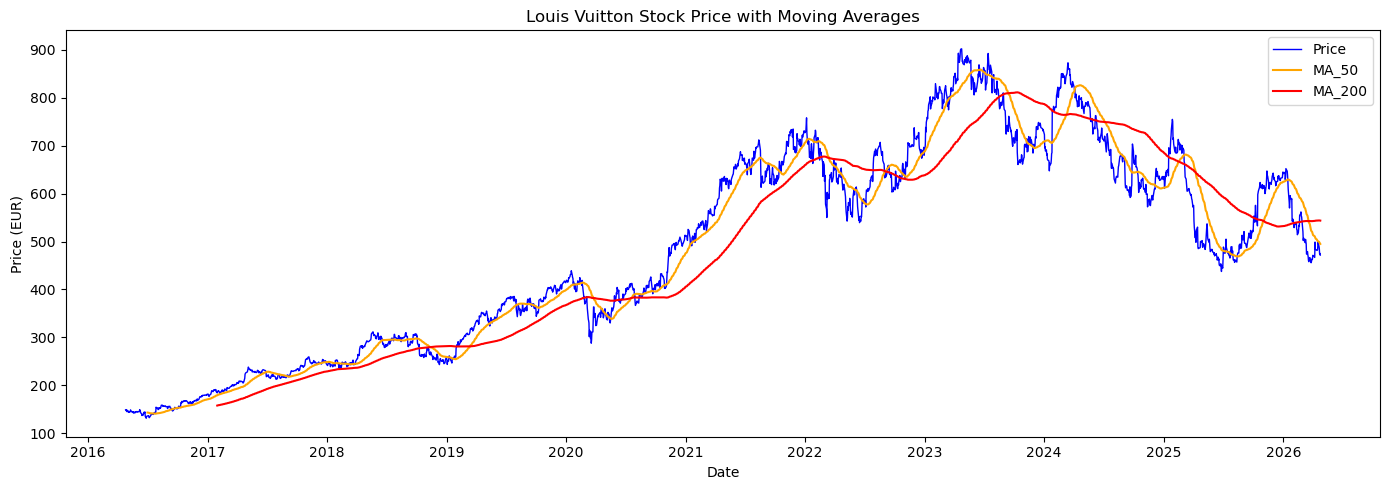

In [6]:
#plot lvmh stock price with 50-day and 200-day moving averages. moving averages help identify long-term trends
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(results["Date"],results["Price"], label="Price", color= "blue", linewidth=1)
ax.plot(results["Date"],results["MA_50"], label="MA_50", color= "orange", linewidth=1.5)
ax.plot(results["Date"],results["MA_200"], label="MA_200", color= "red", linewidth=1.5)

ax.set_title("Louis Vuitton Stock Price with Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price (EUR)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


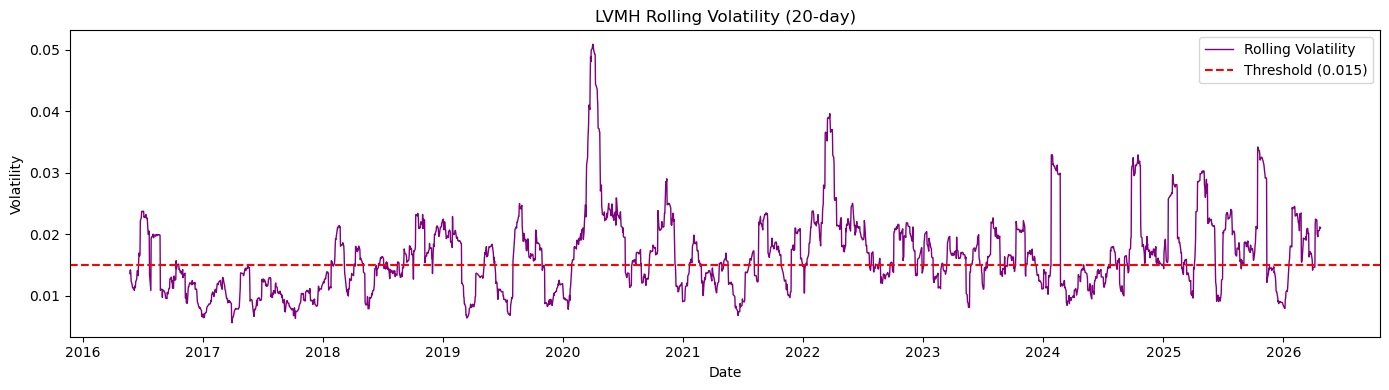

In [7]:
#plot rolling volatility over time. red dashed line indicates risk threshold. days above the threshold ae elevated risk days.
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(results['Date'], results['Volatility'], label='Rolling Volatility', color='purple', linewidth=1)
ax.axhline(y=analyzer.risk_threshold, color='red', linestyle='--', label=f'Threshold ({analyzer.risk_threshold})')

ax.set_title('LVMH Rolling Volatility (20-day)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [8]:
# ger_summary() returns a dict with results compute from analysis
summary = analyzer.get_summary()
print(summary)

{'total_days': 2561, 'high_risk_days': 1370, 'max_drawdown': -0.5149, 'volatility_window': 20, 'risk_threshold': 0.015}


In [9]:
#demonstrate the generator function. risk_signal_generator() yields one signal at a time instead of loading all at once.
print("Risk signals (first 5):")
gen = analyzer.risk_signal_generator()
for i, signal in enumerate(gen):
    if i >= 5:
        break
    print(signal)

Risk signals (first 5):
2016-06-20 | Volatility: 0.0169 | Elevated Risk Detected
2016-06-21 | Volatility: 0.0166 | Elevated Risk Detected
2016-06-22 | Volatility: 0.0165 | Elevated Risk Detected
2016-06-23 | Volatility: 0.0167 | Elevated Risk Detected
2016-06-24 | Volatility: 0.0221 | Elevated Risk Detected
